In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => Temperature
# V  => Vaccum
# AP => Pressure
# RH => humidity

# PE => Produced Energy (Target prediction for ANN)


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# split out data
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
df.shape

(9568, 5)

In [11]:
df.dtypes

AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [14]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [15]:
import torch
import torch.nn as nn

In [16]:
# convert data into tensor
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)


X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [17]:
type(X_train_scaled)

numpy.ndarray

In [18]:
type(y_train)

pandas.Series

In [19]:
y_train

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
         ...  
5734    436.44
5191    441.20
5390    464.26
860     440.45
7270    484.44
Name: PE, Length: 7654, dtype: float64

In [20]:
# DAtaset & Dataloader


In [21]:
from torch.utils.data import TensorDataset, DataLoader

In [22]:
train_dataset  = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,y_test_tensor)

In [23]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [24]:
#  -> Start Deep Learning

In [25]:
# Build the ANN MOdel
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
    
        self.model = nn.Sequential(

            # 1st hidden layer 
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),


            # output layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)


In [26]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

#### Training the ANN Model

In [27]:
# Train the ANN

train_losses = []
valid_losses = []
best_val_loss = float("inf")

epochs = 100
for epoch in range(epochs):
    model.train() #weight update by using the back propagation
    running_loss = 0.0 # total training loss for 1 epoch
    for xb, yb, in train_loader: 
        # xb = feature of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        ouputs = model(xb)  #forward propagatioin.. predicted ouput for this batch
        loss = crietrion(ouputs,yb) # computer loss
        loss.backward() # back propagation .. computer gradients
        optimizer.step() # params update by using the step() parameter



        running_loss += loss.item()  # loss is a tensor => py plot
    epoch_train_loss = running_loss / len(train_loader) # total no.of batches
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():  # no gradient compute
        for xb, yb, in test_loader: 
            ouputs = model(xb)  
            loss = crietrion(ouputs,yb) # computer loss
            running_val_loss += loss # loss is a tensor => py plot
    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)
    print(f" epoch ${epoch + 1}/ {epochs} ==> train loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") # .pt or .pth file extensio


 epoch $1/ 100 ==> train loss = $205895.51204427084 & val loss = $203347.296875
 epoch $2/ 100 ==> train loss = $194285.44375 & val loss = $179866.578125
 epoch $3/ 100 ==> train loss = $154414.36741536457 & val loss = $124487.2421875
 epoch $4/ 100 ==> train loss = $92666.17514648437 & val loss = $63611.7734375
 epoch $5/ 100 ==> train loss = $44418.730342610674 & val loss = $31174.123046875
 epoch $6/ 100 ==> train loss = $25726.359301757813 & val loss = $21887.595703125
 epoch $7/ 100 ==> train loss = $20012.965474446613 & val loss = $17748.427734375
 epoch $8/ 100 ==> train loss = $16290.306223551432 & val loss = $14261.5830078125
 epoch $9/ 100 ==> train loss = $12903.531427001953 & val loss = $10983.9052734375
 epoch $10/ 100 ==> train loss = $9729.549662272135 & val loss = $8024.86572265625
 epoch $11/ 100 ==> train loss = $6912.160675048828 & val loss = $5489.25
 epoch $12/ 100 ==> train loss = $4571.270971679687 & val loss = $3471.1044921875
 epoch $13/ 100 ==> train loss = $2

In [28]:
import matplotlib.pyplot as plt

In [29]:
loss_df = pd.DataFrame({
    "Training loss": train_losses,
    "validation loss":valid_losses
})

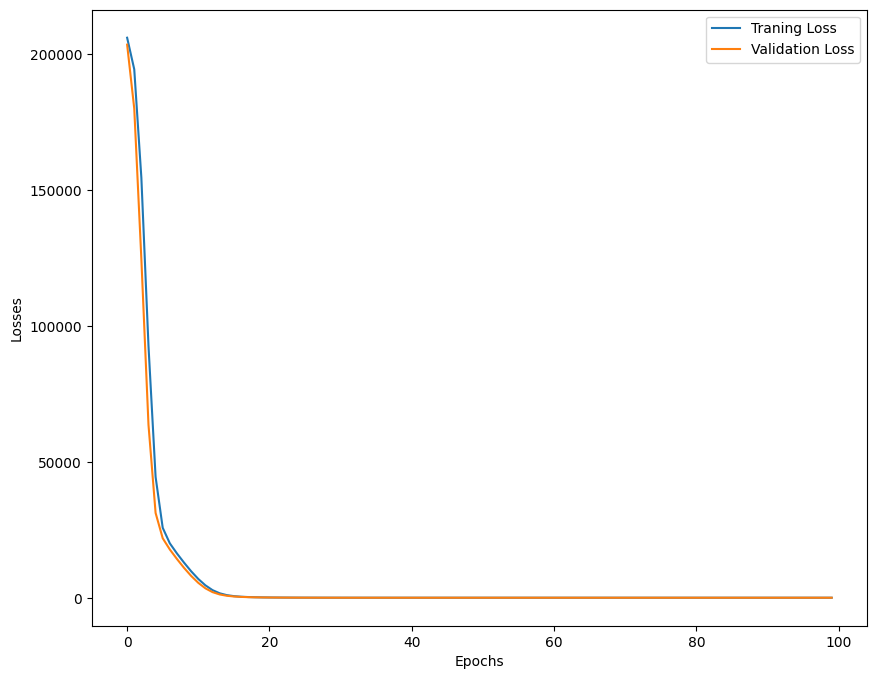

In [30]:
plt.figure(figsize=(10,8))
plt.plot(loss_df["Training loss"],label="Traning Loss")
plt.plot(loss_df["validation loss"],label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

#### Saving and select the best model

In [31]:
# loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

#### Evaluate our Model

In [ ]:
# 1 -> Training MSE
# 2 -> Testing MSE
# 3 -> R2 = r2_score

In [33]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds,y_train_tensor)
    test_mse_loss = crietrion(test_preds,y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())


Training MSE: 20.719640731811523
Testing MSE: 19.018585205078125


In [34]:
from sklearn.metrics import r2_score

In [35]:
print("R2 score ", r2_score(y_test,test_preds))

R2 score  0.9335349559491033


In [38]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.539825,433.27
1,436.869904,438.16
2,460.984558,458.42
3,475.875610,480.82
4,435.183380,441.41
...,...,...
1909,451.413361,456.70
1910,431.703705,438.04
1911,467.833771,467.80
1912,431.076019,437.14
